In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import GroupShuffleSplit

data = pd.read_csv("../../../datasets/Indoor_Plant_Health_and_Growth_Factors.csv")
data.sample(5)

feature_columns  = [
    'Soil_Moisture',
    'Humidity',
    'Ambient_Temperature'
]

target_column = 'Plant_Health_Status'
plant_id_column = 'Plant_ID'

required_columns = feature_columns + [
    target_column,
    plant_id_column,
]

missing_columns = [col for col in required_columns if col not in data.columns]

if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

print("Dataset shape:", data.shape)
print("\nColumn names:")
print(data.columns.tolist())

print("\nData types:")
print(data[required_columns].dtypes)

print("\nMissing values per required column:")
print(data[required_columns].isnull().sum())

print("\nDuplicate rows:", data.duplicated().sum())

Dataset shape: (1000, 17)

Column names:
['Plant_ID', 'Height_cm', 'Leaf_Count', 'New_Growth_Count', 'Health_Notes', 'Watering_Amount_ml', 'Watering_Frequency_days', 'Light_Intensity', 'Ambient_Temperature', 'Humidity', 'Fertilizer_Type', 'Fertilizer_Amount_ml', 'Pest_Presence', 'Pest_Severity', 'Soil_Moisture', 'Soil_Type', 'Plant_Health_Status']

Data types:
Soil_Moisture          float64
Humidity               float64
Ambient_Temperature    float64
Plant_Health_Status      int64
Plant_ID                   str
dtype: object

Missing values per required column:
Soil_Moisture          0
Humidity               0
Ambient_Temperature    0
Plant_Health_Status    0
Plant_ID               0
dtype: int64

Duplicate rows: 0


In [31]:
dataset_columns = feature_columns + [target_column, plant_id_column]
dataset = data[dataset_columns].copy()

before_drop = len(dataset)
dataset = dataset.dropna()
after_drop = len(dataset)

print("\nShape after dropping missing values:", dataset.shape)
print("Rows removed due to missing values:", before_drop - after_drop)

print("\nSample of cleaned dataset:")
print(dataset.sample(min(5, len(dataset))))


Shape after dropping missing values: (1000, 5)
Rows removed due to missing values: 0

Sample of cleaned dataset:
     Soil_Moisture  Humidity  Ambient_Temperature  Plant_Health_Status  \
908           44.4      34.5                 27.9                    5   
797           24.2      66.3                 22.1                    1   
238           23.1      43.1                 24.0                    2   
201           26.5      46.5                 21.2                    2   
628           42.6      75.2                 26.2                    3   

                    Plant_ID  
908     Tradescantia zebrina  
797   Spathiphyllum wallisii  
238       Calathea orbifolia  
201  Philodendron hederaceum  
628     Nephrolepis exaltata  



Target class distribution:
Plant_Health_Status
2    229
5    213
4    205
1    181
3    172
Name: count, dtype: int64


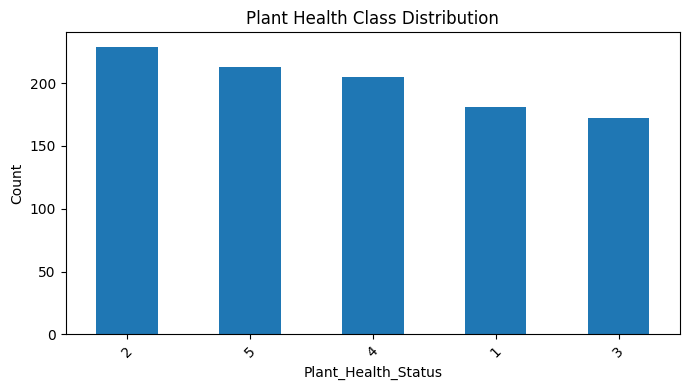

In [32]:
print("\nTarget class distribution:")
print(dataset[target_column].value_counts())

dataset[target_column].value_counts().plot(kind='bar', figsize=(7, 4))
plt.title("Plant Health Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
X = dataset[feature_columns]
y = dataset[target_column]
groups = dataset[plant_id_column]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

x_train = X.iloc[train_idx]
x_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_groups = groups.iloc[train_idx]
test_groups = groups.iloc[test_idx]

print("\nNumber of unique plants in train set:", train_groups.nunique())
print("Number of unique plants in test set:", test_groups.nunique())

overlap = set(train_groups.unique()).intersection(set(test_groups.unique()))
print("Shared Plant_IDs between train and test:", len(overlap))

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(x_train, y_train)

train_predictions = model.predict(x_train)
test_predictions = model.predict(x_test)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print("\nAccuracy:")
print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:  {test_accuracy:.4f}")


Number of unique plants in train set: 16
Number of unique plants in test set: 4
Shared Plant_IDs between train and test: 0



Accuracy:
Train accuracy: 1.0000
Test accuracy:  0.2067


In [34]:
dataset_columns = feature_columns + [target_column, plant_id_column]
dataset = data[dataset_columns].copy()

before_drop = len(dataset)
dataset = dataset.dropna()
after_drop = len(dataset)

print("\nShape after dropping missing values:", dataset.shape)
print("Rows removed due to missing values:", before_drop - after_drop)

print("\nSample of cleaned dataset:")
print(dataset.sample(min(5, len(dataset))))


Shape after dropping missing values: (1000, 5)
Rows removed due to missing values: 0

Sample of cleaned dataset:
     Soil_Moisture  Humidity  Ambient_Temperature  Plant_Health_Status  \
102           37.5      74.5                 25.2                    2   
216           42.5      54.2                 26.6                    1   
624           39.5      67.9                 27.6                    5   
271           19.1      57.6                 23.8                    3   
754           21.9      61.3                 24.4                    4   

                   Plant_ID  
102  Sansevieria cylindrica  
216   Schefflera arboricola  
624               Aloe vera  
271       Epipremnum aureum  
754            Ficus lyrata  



Target class distribution:
Plant_Health_Status
2    229
5    213
4    205
1    181
3    172
Name: count, dtype: int64


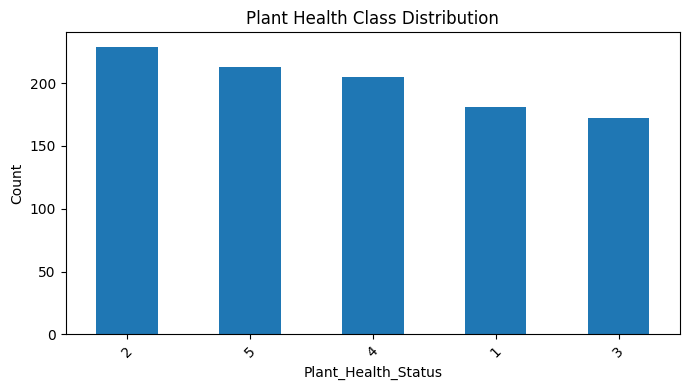

In [35]:
print("\nTarget class distribution:")
print(dataset[target_column].value_counts())

dataset[target_column].value_counts().plot(kind='bar', figsize=(7, 4))
plt.title("Plant Health Class Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
X = dataset[feature_columns]
y = dataset[target_column]
groups = dataset[plant_id_column]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_groups = groups.iloc[train_idx]
test_groups = groups.iloc[test_idx]

print("\nNumber of unique plants in train set:", train_groups.nunique())
print("Number of unique plants in test set:", test_groups.nunique())

overlap = set(train_groups.unique()).intersection(set(test_groups.unique()))
print("Shared Plant_IDs between train and test:", len(overlap))

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print("\nAccuracy:")
print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy:  {test_accuracy:.4f}")


Number of unique plants in train set: 16
Number of unique plants in test set: 4
Shared Plant_IDs between train and test: 0

Accuracy:
Train accuracy: 1.0000
Test accuracy:  0.2067


In [37]:
print("\nTrain set report:")
print(classification_report(y_train, train_predictions))

print("Test set report:")
print(classification_report(y_test, test_predictions))


Train set report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       145
           2       1.00      1.00      1.00       181
           3       1.00      1.00      1.00       130
           4       1.00      1.00      1.00       169
           5       1.00      1.00      1.00       167

    accuracy                           1.00       792
   macro avg       1.00      1.00      1.00       792
weighted avg       1.00      1.00      1.00       792

Test set report:
              precision    recall  f1-score   support

           1       0.17      0.19      0.18        36
           2       0.22      0.27      0.25        48
           3       0.19      0.12      0.15        42
           4       0.19      0.22      0.20        36
           5       0.25      0.22      0.23        46

    accuracy                           0.21       208
   macro avg       0.20      0.20      0.20       208
weighted avg       0.21      0.21      0.

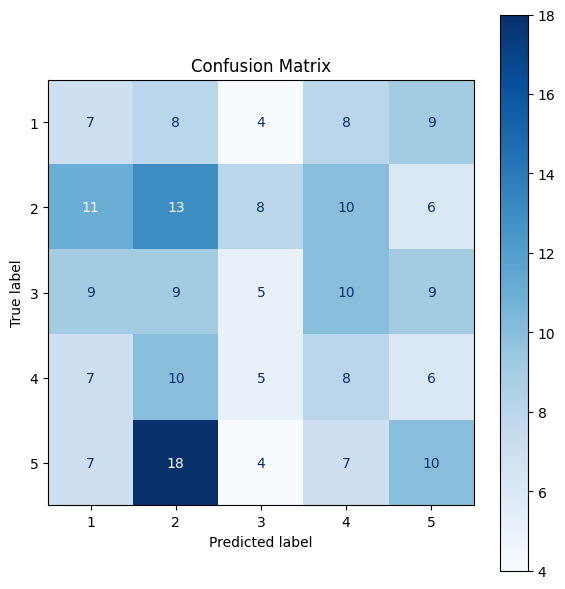

In [38]:
class_labels = sorted(y.unique())

cm = confusion_matrix(y_test, test_predictions, labels=class_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

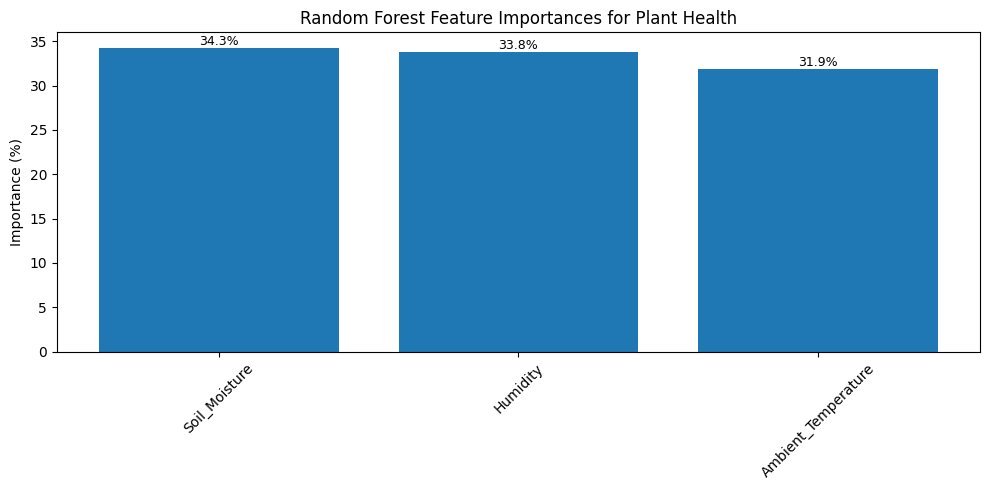

In [39]:
importances = model.feature_importances_
feature_names = X.columns
importances_pct = importances * 100

indices = np.argsort(importances_pct)[::-1]

plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(importances_pct)), importances_pct[indices])

plt.xticks(
    range(len(importances_pct)),
    feature_names[indices],
    rotation=45
)

plt.ylabel("Importance (%)")
plt.title("Random Forest Feature Importances for Plant Health")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [40]:
test_results = X_test.copy()
test_results['Plant_ID'] = test_groups.values
test_results['Actual'] = y_test.values
test_results['Predicted'] = test_predictions

print("\nSample test results:")
print(test_results.head())

print("\nPer-Plant test sample counts:")
print(test_results['Plant_ID'].value_counts().head(10))


Sample test results:
    Soil_Moisture  Humidity  Ambient_Temperature                Plant_ID  \
0            51.9      77.5                 21.7  Sansevieria cylindrica   
1            28.2      68.9                 22.6               Aloe vera   
13           51.2      41.5                 24.4  Spathiphyllum wallisii   
16           41.4      38.6                 23.5               Aloe vera   
20           43.8      53.8                 21.5    Aglaonema commutatum   

    Actual  Predicted  
0        1          3  
1        2          2  
13       5          4  
16       2          3  
20       2          2  

Per-Plant test sample counts:
Plant_ID
Aloe vera                 55
Sansevieria cylindrica    52
Aglaonema commutatum      52
Spathiphyllum wallisii    49
Name: count, dtype: int64


In [41]:
print("\nDataset Validation Summary")
print("--------------------------")
print(f"Original rows: {len(data)}")
print(f"Rows used after cleaning: {len(dataset)}")
print(f"Features used: {feature_columns}")
print(f"Target classes: {sorted(y.unique().tolist())}")
print(f"Missing values removed: {before_drop - after_drop}")
print(f"Duplicate rows in original data: {data.duplicated().sum()}")
print(f"Unique Plant_IDs total: {dataset[plant_id_column].nunique()}")
print(f"Unique Plant_IDs in train: {train_groups.nunique()}")
print(f"Unique Plant_IDs in test: {test_groups.nunique()}")
print(f"Shared Plant_IDs between train/test: {len(overlap)}")
print(f"Train accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


Dataset Validation Summary
--------------------------
Original rows: 1000
Rows used after cleaning: 1000
Features used: ['Soil_Moisture', 'Humidity', 'Ambient_Temperature']
Target classes: [1, 2, 3, 4, 5]
Missing values removed: 0
Duplicate rows in original data: 0
Unique Plant_IDs total: 20
Unique Plant_IDs in train: 16
Unique Plant_IDs in test: 4
Shared Plant_IDs between train/test: 0
Train accuracy: 1.0000
Test accuracy: 0.2067


Soil_Moisture          0.003656
Humidity               0.031807
Ambient_Temperature    0.064063
Plant_Health_Status    1.000000
Name: Plant_Health_Status, dtype: float64


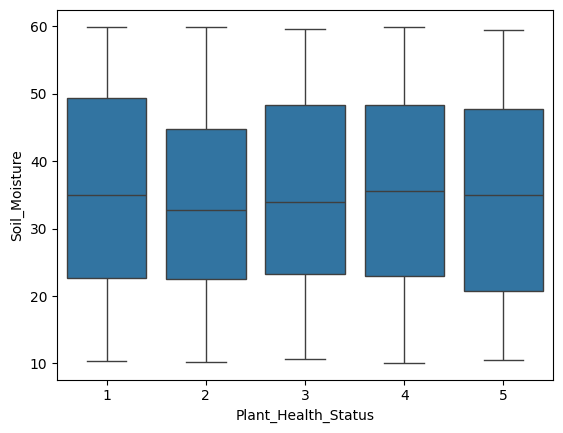

In [42]:
import seaborn as sns

dataset_numeric = dataset.copy()
print(dataset_numeric.corr(numeric_only=True)['Plant_Health_Status'])

sns.boxplot(x='Plant_Health_Status', y='Soil_Moisture', data=dataset)
plt.show()